## TF-IDF Keyword Analysis – Google Discontinued Products

Using TF-IDF (Term Frequency-Inverse Document Frequency) to find the most important keywords in YouTube comments for each product, split by before/after discontinuation.

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer

### Load data from all 6 CSV files

In [2]:
def load_csv(path, product, period):
    df = pd.read_csv(path)
    df['product'] = product
    df['period'] = period
    return df

frames = [
    load_csv('old_stadia_youtube_comments_raw.csv',          'stadia',       'before'),
    load_csv('recent_stadia_youtube_comments_raw.csv',       'stadia',       'after'),
    load_csv('old_google_glass_youtube_comments_raw.csv',    'google_glass', 'before'),
    load_csv('recent_google_glass_youtube_comments_raw.csv', 'google_glass', 'after'),
    load_csv('old_plus_youtube_comments_raw.csv',            'google_plus',  'before'),
    load_csv('recent_plus_youtube_comments_raw.csv',         'google_plus',  'after'),
]
df = pd.concat(frames, ignore_index=True)
print('total rows:', len(df))

total rows: 3455


### Clean text

In [3]:
def clean(text):
    text = str(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip().lower()

df['clean_comment'] = df['comment'].apply(clean)
df = df.drop_duplicates(subset=['clean_comment'])
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))
df = df[df['word_count'] >= 4].reset_index(drop=True)
print('rows after cleaning:', len(df))

rows after cleaning: 3253


### TF-IDF per product and period

For each group, we fit a TF-IDF vectorizer and extract the top 15 terms. Unigrams and bigrams (1-2 word phrases) are both included.

In [4]:
custom_stops = ['google','stadia','glass','plus','would','could','really','just',
                'like','know','think','still','even','back','one','get','got',
                'make','made','want','way','also','much','never','said','going',
                'come','came','thing','people','time','year','years','new','good','great']

results = {}
for prod in ['stadia', 'google_glass', 'google_plus']:
    results[prod] = {}
    for period in ['before', 'after']:
        subset = df[(df['product']==prod) & (df['period']==period)]['clean_comment']
        tfidf = TfidfVectorizer(max_features=300, stop_words='english',
                                ngram_range=(1,2), min_df=2,
                                token_pattern=r'(?u)\b[a-z]{3,}\b')
        matrix = tfidf.fit_transform(subset)
        scores = zip(tfidf.get_feature_names_out(), matrix.sum(axis=0).A1)
        top = [w for w,s in sorted(scores, key=lambda x: x[1], reverse=True)
               if w not in custom_stops][:15]
        results[prod][period] = top
        print(f'{prod} | {period}: {top[:10]}')

stadia | before: ['gaming', 'internet', 'video', 'play', 'future', 'game', 'google stadia', 'console', 'games', 'austin']
stadia | after: ['games', 'video', 'game', 'play', 'gaming', 'remember', 'controller', 'didn', 'internet', 'did']
google_glass | before: ['google glass', 'apple', 'vision', 'pro', 'glasses', 'vision pro', 'video', 'watching', 'apple vision', 'ahead']
google_glass | after: ['apple', 'google glass', 'glasses', 'video', 'vision', 'tech', 'camera', 'pro', 'vision pro', 'remember']
google_plus | before: ['youtube', 'video', 'facebook', 'love', 'song', 'don', 'use', 'comments', 'awesome', 'thanks']
google_plus | after: ['remember', 'google plus', 'used', 'use', 'youtube', 'don', 'social', 'miss', 'video', 'friends']


### Visualize top keywords – before vs after

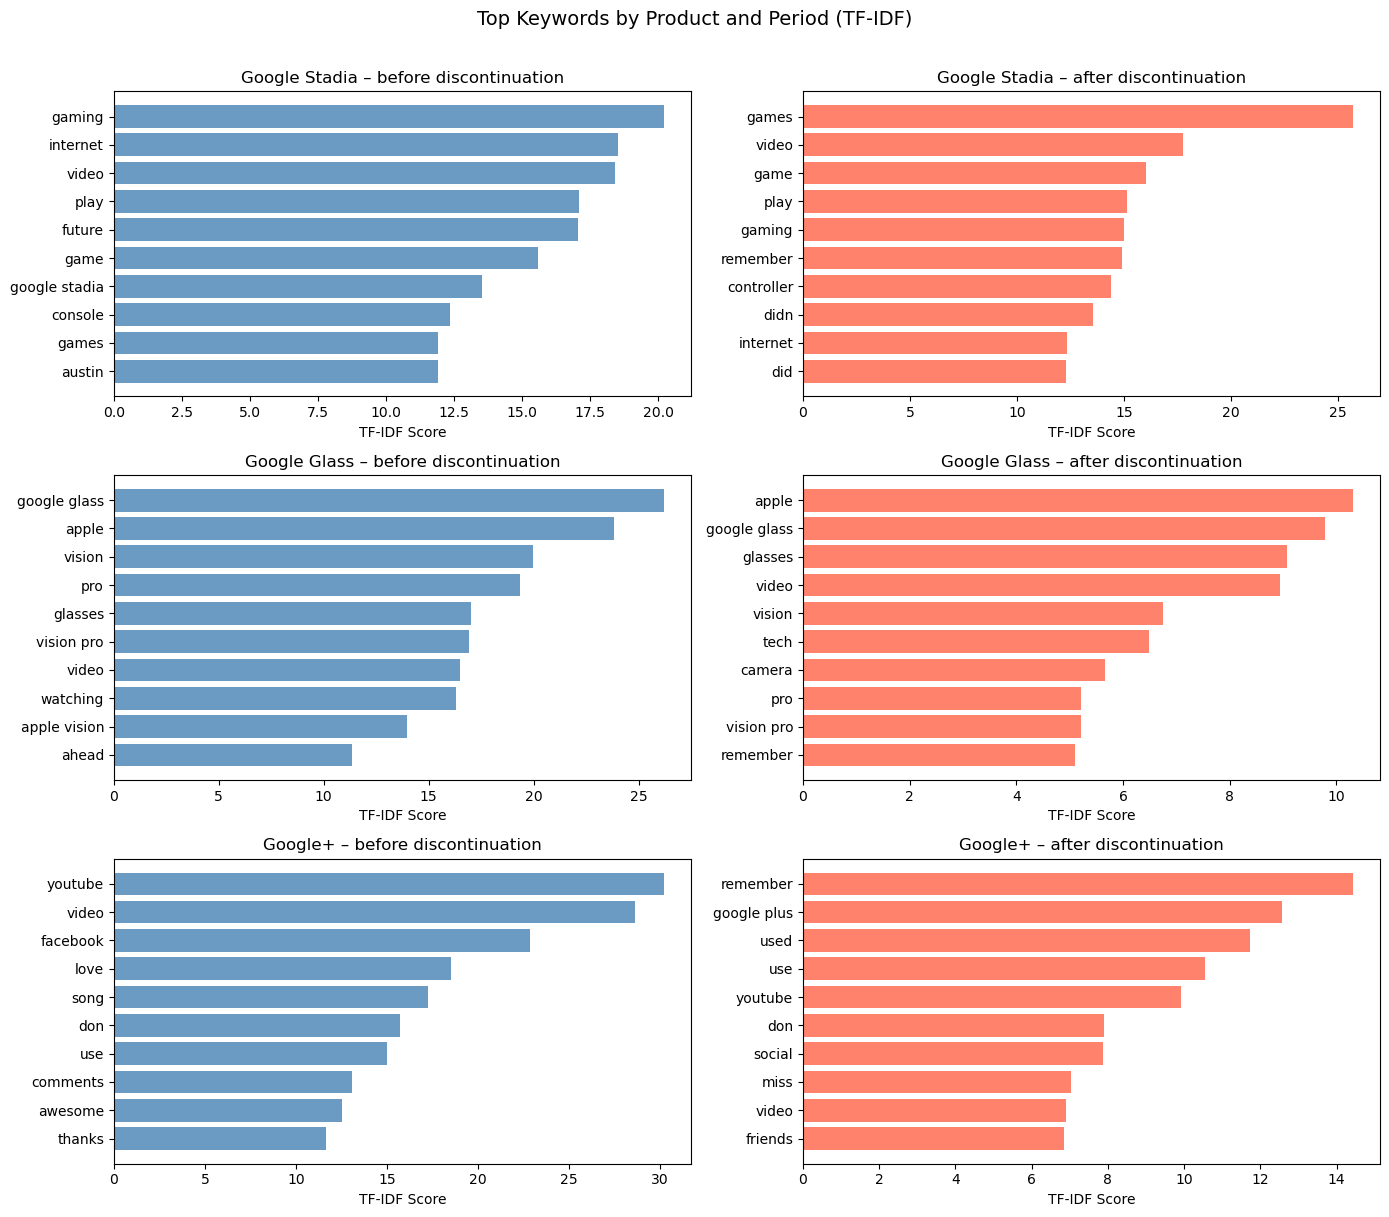

saved tfidf_keywords.png


In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
prod_labels = {'stadia': 'Google Stadia', 'google_glass': 'Google Glass', 'google_plus': 'Google+'}

for row, prod in enumerate(['stadia', 'google_glass', 'google_plus']):
    for col, period in enumerate(['before', 'after']):
        ax = axes[row][col]
        words = results[prod][period][:10]
        subset = df[(df['product']==prod) & (df['period']==period)]['clean_comment']
        tfidf = TfidfVectorizer(max_features=300, stop_words='english',
                                ngram_range=(1,2), min_df=2,
                                token_pattern=r'(?u)\b[a-z]{3,}\b')
        matrix = tfidf.fit_transform(subset)
        score_dict = dict(zip(tfidf.get_feature_names_out(), matrix.sum(axis=0).A1))
        filtered = [(w, score_dict[w]) for w in results[prod][period]
                    if w in score_dict][:10]
        if not filtered:
            continue
        words_plot, scores_plot = zip(*filtered)
        color = 'steelblue' if period == 'before' else 'tomato'
        ax.barh(list(words_plot)[::-1], list(scores_plot)[::-1], color=color, alpha=0.8)
        ax.set_title(f'{prod_labels[prod]} – {period} discontinuation')
        ax.set_xlabel('TF-IDF Score')

plt.suptitle('Top Keywords by Product and Period (TF-IDF)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('tfidf_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved tfidf_keywords.png')

### Key observations

After discontinuation, the word **'remember'** appears in the top terms for all three products — suggesting a shift from active discussion to nostalgia. For Google Glass, comparisons to **Apple Vision Pro** dominate both periods, showing it is still used as a reference point in AR/VR conversations. For Google+, **'miss'** and **'used'** appear post-discontinuation, reflecting how users processed losing the platform.

In [6]:
# Save results to CSV for reference
rows = []
for prod in results:
    for period in results[prod]:
        for rank, word in enumerate(results[prod][period], 1):
            rows.append({'product': prod, 'period': period, 'rank': rank, 'keyword': word})
tfidf_df = pd.DataFrame(rows)
tfidf_df.to_csv('tfidf_keywords.csv', index=False)
print('saved tfidf_keywords.csv')
print(tfidf_df.head(12))

saved tfidf_keywords.csv
   product  period  rank        keyword
0   stadia  before     1         gaming
1   stadia  before     2       internet
2   stadia  before     3          video
3   stadia  before     4           play
4   stadia  before     5         future
5   stadia  before     6           game
6   stadia  before     7  google stadia
7   stadia  before     8        console
8   stadia  before     9          games
9   stadia  before    10         austin
10  stadia  before    11  future gaming
11  stadia  before    12            don
